# Mutações
### Imports

In [223]:
from random import randint, choices, sample, uniform, seed
import numpy as np
import cupy as cp
import cupyx.scipy.ndimage as scimg
import cupyx.scipy.signal as scicon
import math
import imageio.v3 as imio
from PIL import Image, ImageFile, ImageOps
import cv2

import classes.pokedex as pokedex
import classes.mutation as mutation
import classes.utils as utils


%matplotlib inline 
from matplotlib import pyplot as plt


### Gets

In [224]:

pkd = pokedex.Pokedex(target_dex='809', score_type='rgba')
mut = mutation.Mutation()

9
rgba
<class 'cupy.ndarray'>


KeyboardInterrupt: 

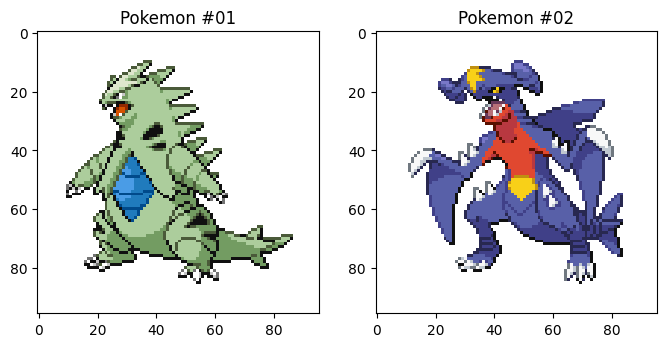

In [ ]:
pk1 = pkd.load_pokepng('248')

pk2 = pkd.load_pokepng('445')

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('Pokemon #01')
axis[0].imshow(cp.asnumpy(pk1), interpolation='nearest')
axis[1].set_title('Pokemon #02')
axis[1].imshow(cp.asnumpy(pk2), interpolation='nearest')


plt.show()



## Testes

### Rotações

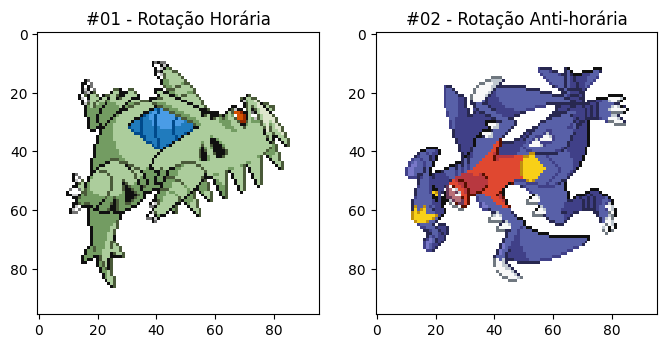

In [ ]:
pk_mut1 = cp.rot90(pk1, k=-1)
pk_mut2 = cp.rot90(pk2, k=1)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Rotação Horária')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Rotação Anti-horária')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


plt.show()

### Espelhamento

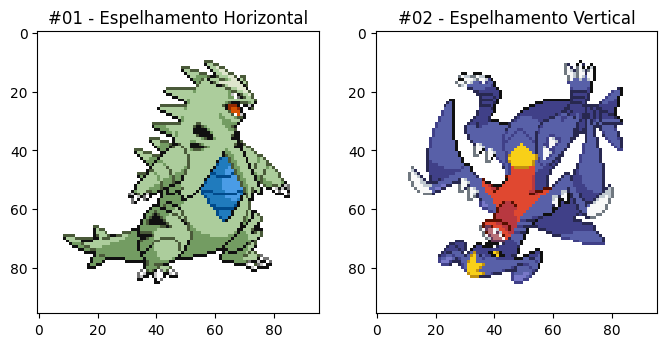

In [ ]:
pk_mut1 = cp.fliplr(pk1)
pk_mut2 = cp.flipud(pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Espelhamento Horizontal')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Espelhamento Vertical')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


plt.show()

### Espelhamento Divisório

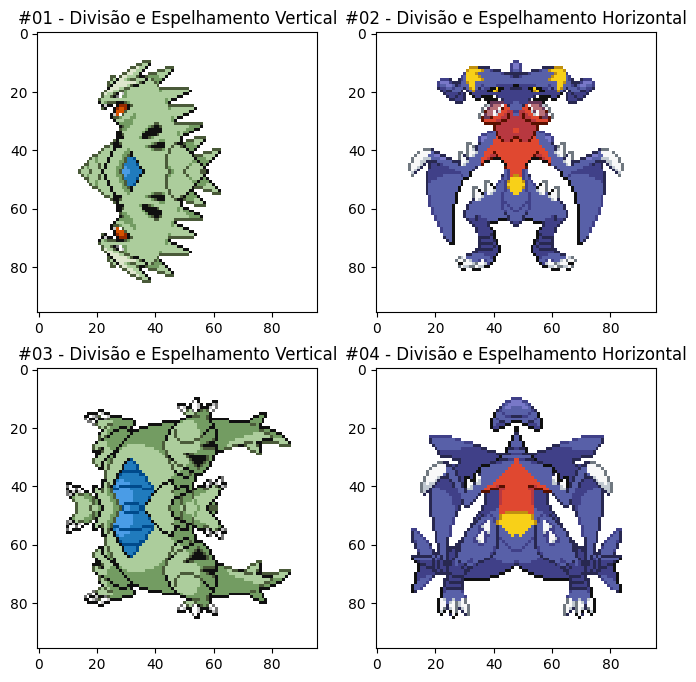

In [ ]:
v_half = pk1.shape[0] // 2
pk_mut1a = cp.vstack((pk1[:v_half], cp.flipud(pk1[:v_half])))
pk_mut1b = cp.vstack((cp.flipud(pk1[v_half:]), pk1[v_half:]))
    
h_half = pk2.shape[1] // 2
pk_mut2a = cp.hstack((pk2[:, :h_half], cp.fliplr(pk2[:, :h_half])))
pk_mut2b = cp.hstack((cp.fliplr(pk2[:, h_half:]), pk2[:, h_half:]))
    
    
figure, axis = plt.subplots(2, 2, figsize=(8, 8))
axis[0,0].set_title('#01 - Divisão e Espelhamento Vertical')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Divisão e Espelhamento Horizontal')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Divisão e Espelhamento Vertical')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Divisão e Espelhamento Horizontal')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')


plt.show()

## Conversões
### Preto e Branco

(96, 96)


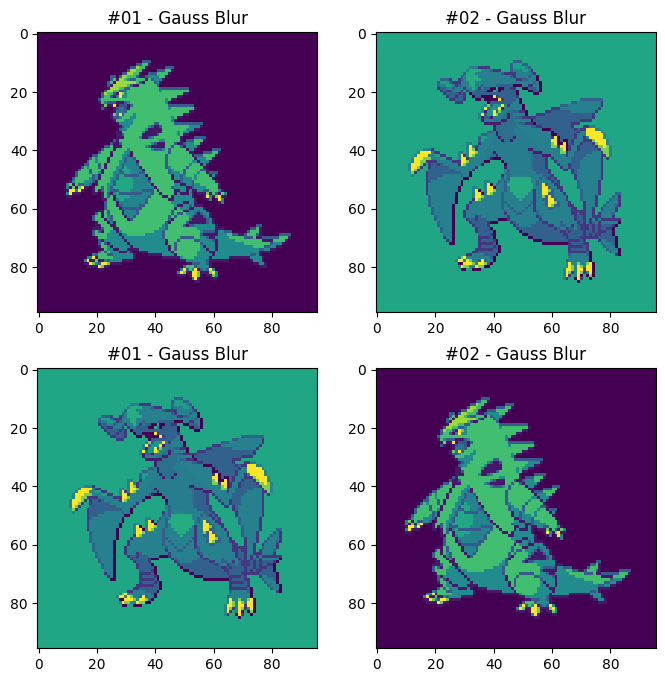

In [ ]:
pk_mut1 = cp.mean(pk1[:,:,:3], axis=2)
pk_mut2 = cp.mean(pk2[:,:,:3], axis=2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Gauss Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Gauss Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Threshold/Binario

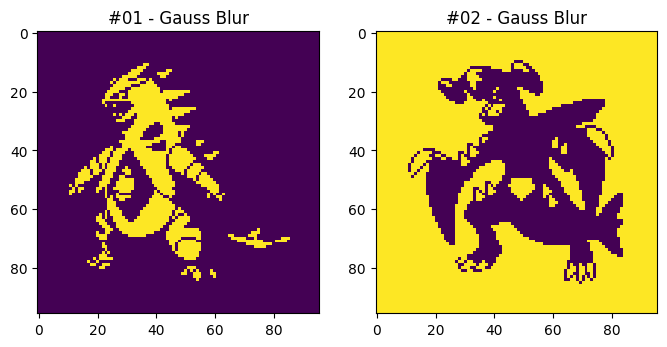

In [ ]:
pk_mut1 = cp.mean(pk1[:,:,:3], axis=2)
pk_mut2 = cp.mean(pk2[:,:,:3], axis=2)

pk_mut1[pk_mut1[:,:] < 128] = 0
pk_mut1[pk_mut1[:,:] >= 128] = 255

pk_mut2[pk_mut2[:,:] < 128] = 0
pk_mut2[pk_mut2[:,:] >= 128] = 255

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Gauss Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Gauss Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

## Filtros
### Gaussian Blur

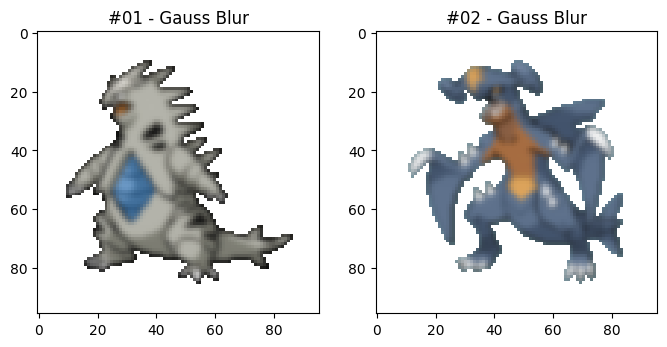

In [446]:
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,0:3] = scimg.gaussian_filter(pk1[:,:,:3], sigma=1)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,0:3] = scimg.gaussian_filter(pk2[:,:,:3], sigma=1)
#mk = pk2[:,:,3] > 0
#pk_mut2[mk,3] = 255

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Gauss Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Gauss Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Box Blur

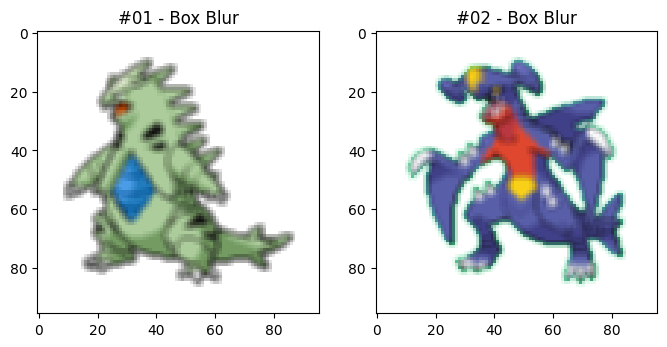

In [ ]:
kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
])/9.0

pk_mut1 = scimg.convolve(pk1, kernel)
pk_mut2 = scimg.convolve(pk2, kernel)
mk = pk2[:,:,3] > 0
pk_mut2[mk,3] = 255


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Box Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Box Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Mediana

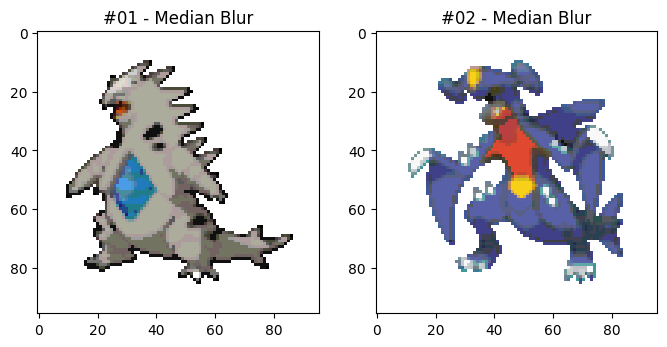

In [ ]:
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,0:3] = scimg.median_filter(pk1[:,:,:3],size=3)


#pk_mut1 = scimg.convolve(pk1, weights=[])
#pk_mut1 = scicon.convolve2d()
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,0:3] = scimg.median_filter(pk2[:,:,:3], size=3)
#pk_mut2 = cv2.medianBlur(cp.asnumpy(pk2), 3)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Median Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Median Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Máximo/Mínimo

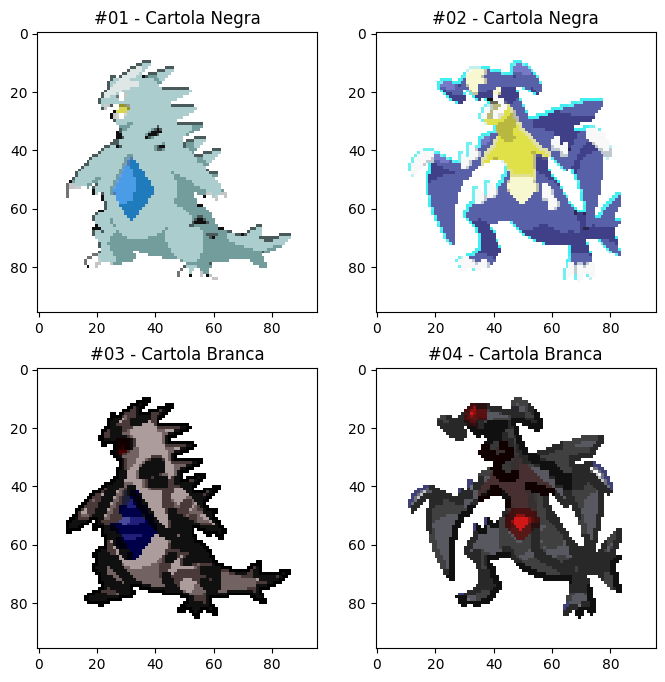

In [ ]:
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,0:3] = scimg.maximum_filter(pk1[:,:,:3],size=2)
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,0:3] = scimg.maximum_filter(pk2[:,:,:3],size=2)

#pk_mut1 = scimg.convolve(pk1, weights=[])
#pk_mut1 = scicon.convolve2d()
pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,0:3] = scimg.minimum_filter(pk1[:,:,:3], size=3)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,0:3] = scimg.minimum_filter(pk2[:,:,:3], size=3)
#pk_mut2 = cv2.medianBlur(cp.asnumpy(pk2), 3)


figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Cartola Negra')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Cartola Negra')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Cartola Branca')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Cartola Branca')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

### aaa

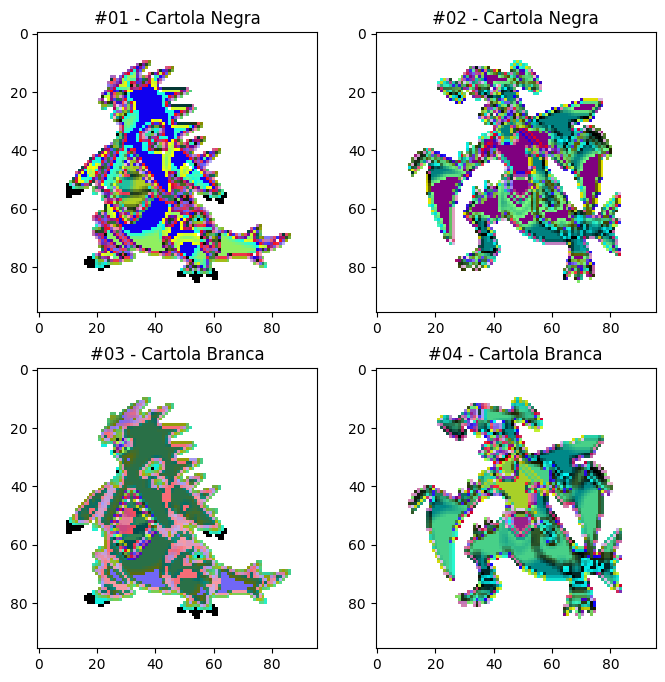

In [ ]:
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,:3] = scimg.sobel(pk1[:,:,:3])
#pk_mut2a = cp.copy(pk2)

#pk_mut2a = scimg.zoom(pk2, [4,4,1], mode='nearest', prefilter=False, order=0)
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,:3] = scimg.sobel(pk2[:,:,:3])

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,:3]  = scimg.prewitt(pk1[:,:,:3])
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,0:3] = scimg.prewitt(pk2[:,:,:3])


figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Sobel')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Sobel')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Prewitt')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Prewitt')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

### Sharpen

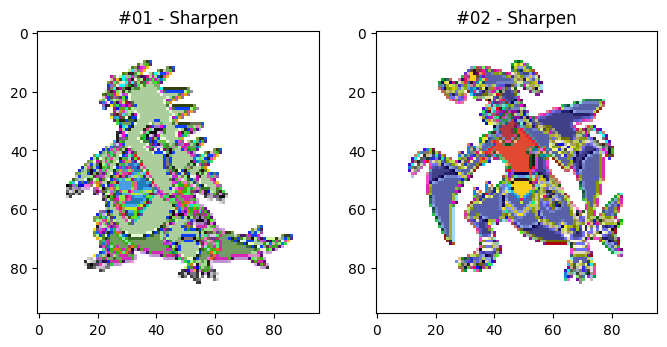

In [ ]:
kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.convolve(pk1[:,:,:3], kernel)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.convolve(pk2[:,:,:3], kernel)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Sharpen')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Sharpen')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Bordas

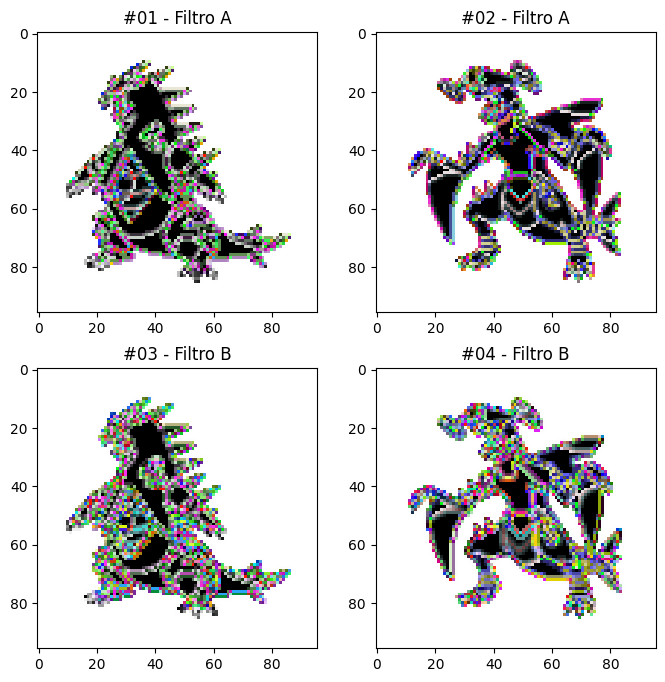

In [421]:
mk1 = pk1[:,:,3] == 255
mk2 = pk2[:,:,3] == 255

kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0],
])

pk_mut1a =  scimg.convolve(pk1, kernel)
pk_mut2a = scimg.convolve(pk2, kernel)
kernel[:,:,0] = cp.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1],
])
pk_mut1b =  scimg.convolve(pk1, kernel)
pk_mut2b = scimg.convolve(pk2, kernel)

pk_mut1a[mk1,3] = 255
pk_mut1b[mk1,3] = 255
pk_mut2a[mk2,3] = 255
pk_mut2b[mk2,3] = 255

figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Filtro A')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Filtro A')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Filtro B')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Filtro B')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

## Morfologia
### Erosão

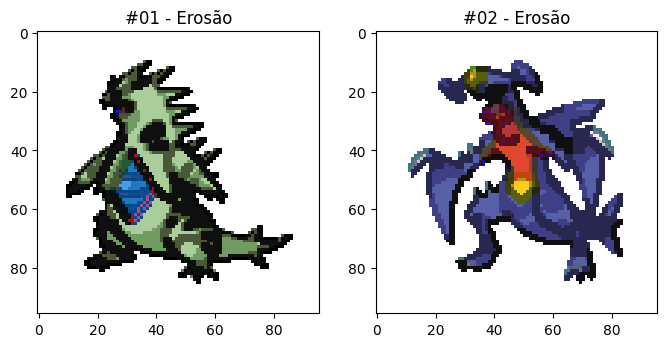

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
#pk_mut1[:,:,:3] = scimg.convolve(pk1[:,:,:3], kernel)
#pk_mut1[:,:,:3] = scimg.grey_erosion(pk1[:,:,:3], size=3)
pk_mut1[:,:,:3] = scimg.grey_erosion(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_erosion(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Erosão')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Erosão')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Dilatação

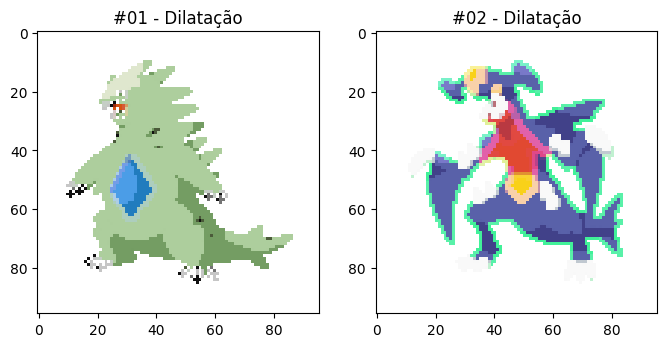

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.grey_dilation(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_dilation(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Dilatação')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Dilatação')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Abertura

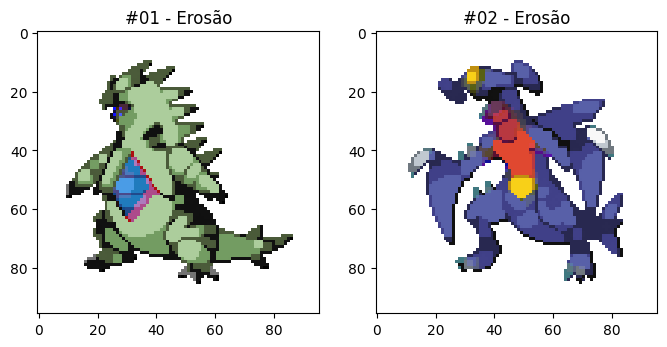

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.grey_opening(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_opening(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Abertura')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Abertura')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Fechamento

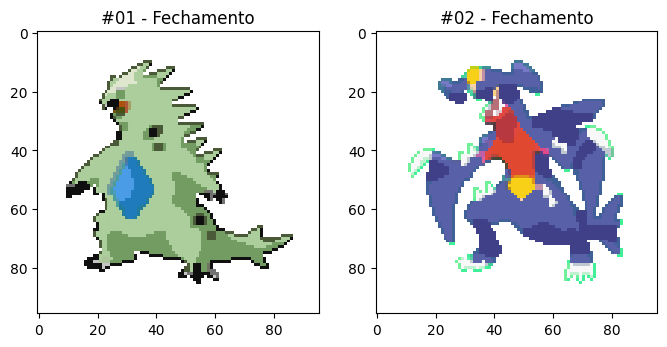

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.grey_closing(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_closing(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Fechamento')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Fechamento')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Cartola Branca/Negra

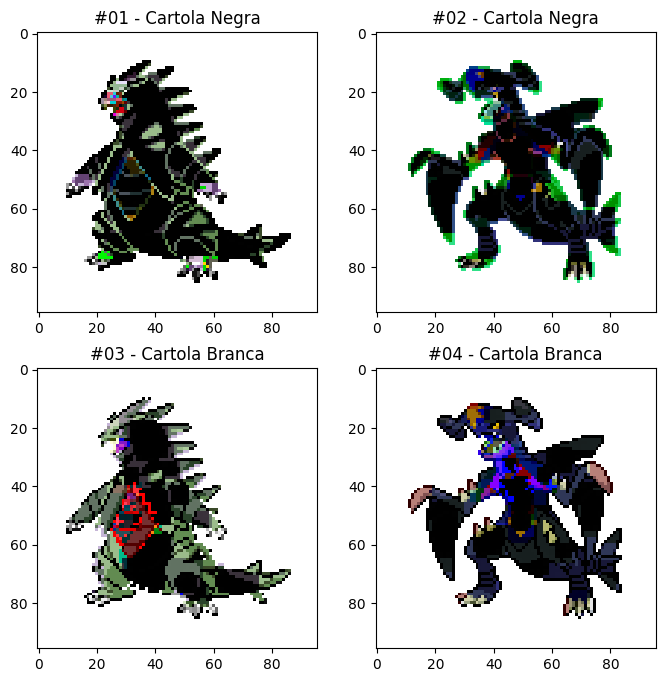

In [ ]:
mask = cp.zeros((5,5,1))
mask[:,:,0] = cp.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0]
])
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,:3] = scimg.black_tophat(pk1[:,:,:3], structure=mask)
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,:3] = scimg.black_tophat(pk2[:,:,:3], structure=mask)

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,:3] = scimg.white_tophat(pk1[:,:,:3], structure=mask)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,:3] = scimg.white_tophat(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Cartola Negra')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Cartola Negra')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Cartola Branca')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Cartola Branca')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

### Morfologia - Outros

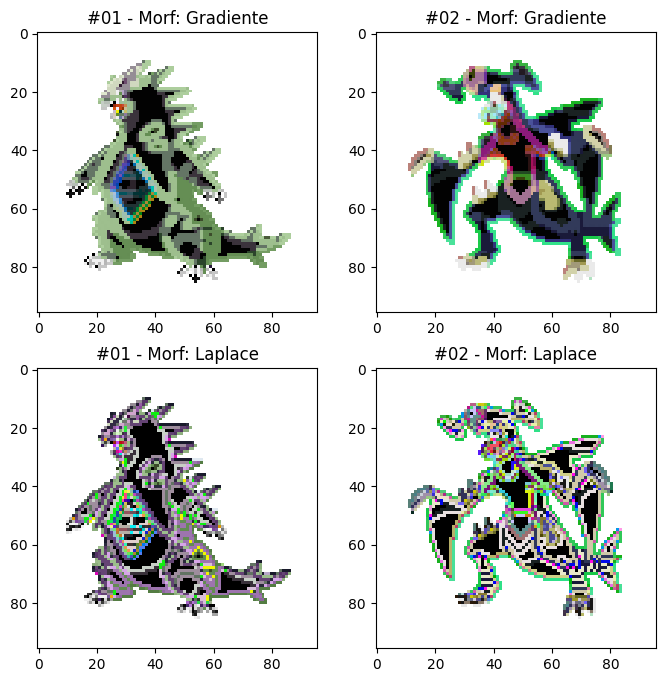

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,:3] = scimg.morphological_gradient(pk1[:,:,:3], structure=mask)

pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,:3] = scimg.morphological_gradient(pk2[:,:,:3], structure=mask)

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,:3] = scimg.morphological_laplace(pk1[:,:,:3], structure=mask)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,:3] = scimg.morphological_laplace(pk2[:,:,:3], structure=mask)

figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Morf: Gradiente')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Morf: Gradiente')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#01 - Morf: Laplace')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#02 - Morf: Laplace')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

## Outros
### Shuffle

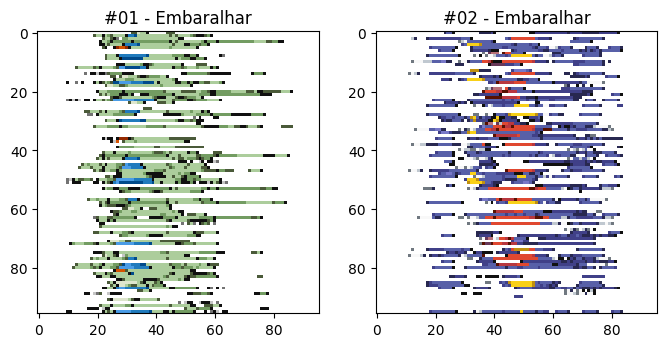

In [ ]:

pk_mut1 = cp.copy(pk1)
pk_mut2 = cp.copy(pk2)
cp.random.shuffle(pk_mut1)
cp.random.shuffle(pk_mut2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Embaralhar')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Embaralhar')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


### Inverter

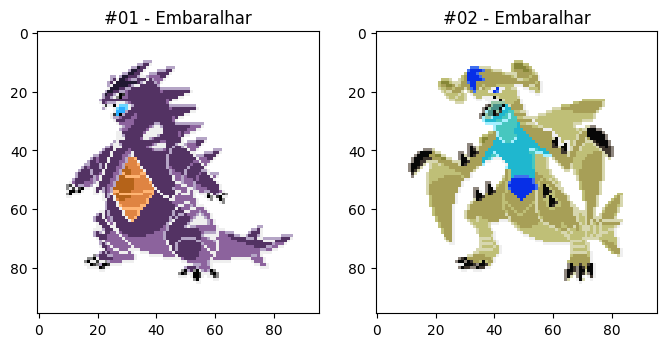

In [ ]:
pk_mut1 = cp.copy(pk1)
pk_mut2 = cp.copy(pk2)

mk1 = pk1[:,:,3] != 255
mk2 = pk2[:,:,3] != 255
pk_mut1[:,:,:3] = cp.bitwise_not(pk1[:,:,:3])
pk_mut2[:,:,:3] = cp.bitwise_not(pk2[:,:,:3])

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Inverter')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Inverter')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


In [ ]:
def mutate(self, pk_img):
        
        mutation_type = randint(0, 10)
        #print(f'Tipo de mutação:{mutation_type}')
        match mutation_type:
            #case 5:
                #pk_img = utils.to_rgba(utils.to_grayscale(pk_img))
            #case 6:
                #pk_img = utils.to_rgba(utils.to_black_n_white(pk_img))
            #case 7:
                #pk_img = utils.posterize(pk_img)
            #case 8:
                #pk_img = utils.posterize_hard(pk_img)
            #case 9:
                #cl = choices([(True, False, False), (False, True, False), (False, False, True), (True, True, False), (True, False, True), (False, True, True)], k=1)
                #pk_img = utils.to_monochrome(pk_img, cl[0][0], cl[0][1], cl[0][2])
            #case 12:
                #pk_img = utils.fit_img(pk_img)
            #case 28:
                ####gauss = scimg.gaussian_filter(pk_img, sigma=2)
                #gauss = cv2.GaussianBlur(np.copy(pk_img), (3,3),0)
                #mk = gauss[:,:,3] > 0
                #pk_img = cv2.addWeighted(pk_img, 2.0, gauss, -1.0, 0)
                #pk_img[mk,3] = 255
            #case 29:
                #pk_img = self.visible_mono(pk_img)
            #case 30:
                #pk_img = utils.bayer_dithering_RGB(pk_img)
            #case 31:
                #pk_img = utils.bayer_dithering_BY(pk_img)   
        
        #if randint(0,9) == 9:
        #    pk_img = self.mutate(pk_img=pk_img)
        
        return pk_img